#  Regime-Switching Time Series Analysis

## Introduction

Financial and economic time series often exhibit nonlinear dynamics, structural breaks, and periods of instability. Traditional linear models fail to capture these changes effectively.

To address this, we employ a **Markov Regime-Switching Model**, which allows the data-generating process to switch between different states (regimes), each with its own statistical properties.

This approach captures:
- Structural changes
- Volatility clustering
- Economic cycles (e.g., stable vs crisis periods)

---

## Objective

The objective of this study is to:
- Model regime changes in the time series
- Estimate regime-specific parameters
- Analyze transition probabilities
- Interpret economic meaning of regimes

## Data and Libraries

We use daily adjusted closing prices of Apple Inc. (AAPL), obtained via API.

All analysis is conducted in Python using standard econometric libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import scipy.stats as stats

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings('ignore')

## Data Acquisition

We download daily stock prices for Apple Inc. from 2018 to 2025.

In [ ]:
df_raw = yf.download("AAPL", start="2018-01-01", end="2025-12-31")

if not df_raw.empty:
    # Flatten multi-level columns if they exist to simplify access
    if isinstance(df_raw.columns, pd.MultiIndex):
        df_raw.columns = ['_'.join(col).strip() for col in df_raw.columns.values]

    # Find the appropriate price column
    price_col_name = None
    # Prioritize 'Adj Close'
    for col in df_raw.columns:
        if 'adj close' in col.lower():
            price_col_name = col
            break

    # If 'Adj Close' not found, look for 'Close'
    if price_col_name is None:
        for col in df_raw.columns:
            if 'close' in col.lower():
                price_col_name = col
                break

    if price_col_name:
        df = df_raw[[price_col_name]].rename(columns={price_col_name: 'price'})
    else:
        print("Warning: No suitable 'Adj Close' or 'Close' column found. Falling back to empty DataFrame.")
        df = pd.DataFrame(columns=['price'])
else:
    df = pd.DataFrame(columns=['price'])
    print("Warning: yfinance.download returned an empty DataFrame. Check ticker or date range.")

[*********************100%***********************]  1 of 1 completed


## Log Returns

Returns are computed as:

$$
r_t = \ln(P_t) - \ln(P_{t-1})
$$

We compute these for both daily and monthly frequencies.

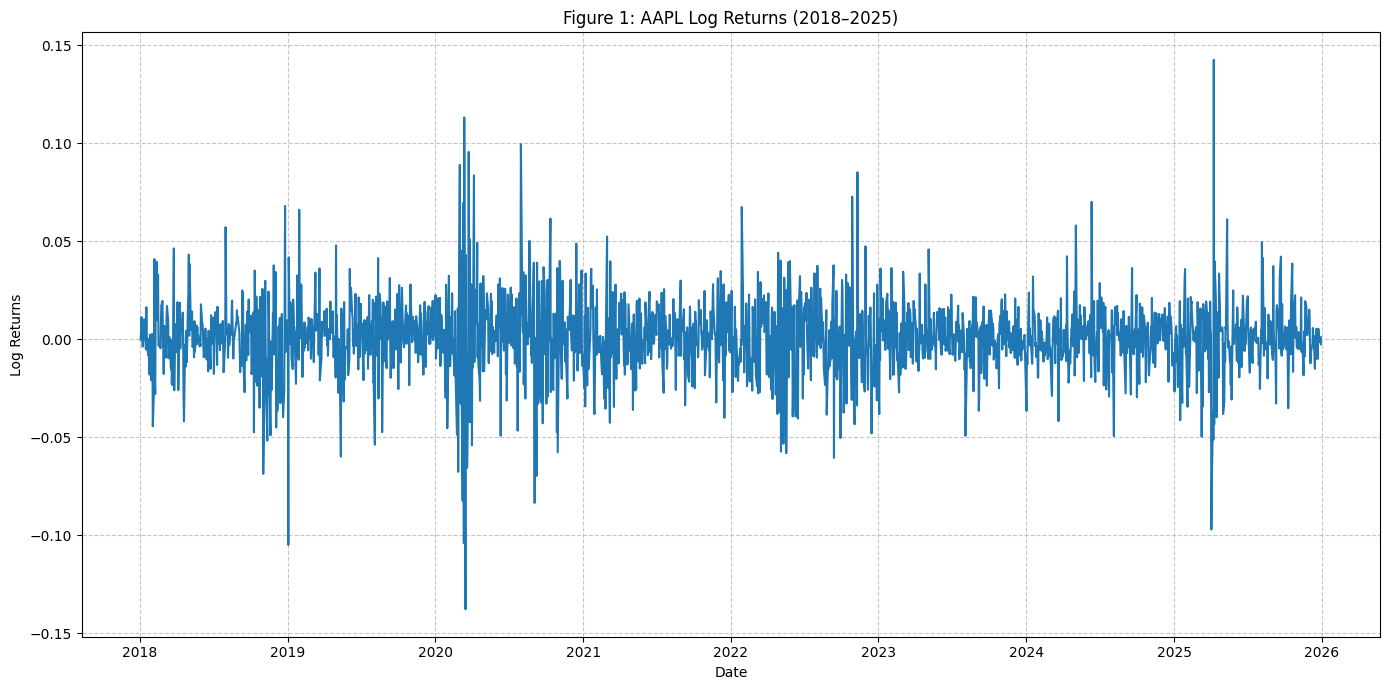

In [ ]:
# Calculate log returns only if the DataFrame is not empty and has the 'price' column
if not df.empty and 'price' in df.columns:
    df['returns'] = np.log(df['price']).diff()
    df = df.dropna()
else:
    df = pd.DataFrame(columns=['price', 'returns']) # Ensure df has expected columns if empty
    print("Warning: DataFrame 'df' is empty or missing 'price' column. Cannot calculate returns.")

plt.figure(figsize=(14,7))
plt.plot(df['returns'])
plt.title("Figure 1: AAPL Log Returns (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Log Returns (Figure 1)

Figure 1 displays the daily log returns for Apple Inc. (AAPL) from 2018 to 2025. This plot is crucial for observing the raw volatility and general trends in the stock's price movements. We can visually identify periods of higher and lower volatility, which is a key characteristic we expect the Markov Regime-Switching model to capture.

*   **Volatility Clusters:** Noticeable periods where large price changes (returns) are followed by large price changes, and small changes are followed by small changes, indicating volatility clustering. This suggests that the assumption of constant variance (homoscedasticity) might not hold, making a regime-switching variance model appropriate.
*   **Mean Reversion:** While not explicitly visible from this plot alone, log returns often exhibit properties closer to stationarity compared to raw prices, making them suitable for time series modeling.

This initial visualization sets the stage for further statistical tests and regime-switching analysis.

## Stationarity Test (ADF)

We test for stationarity using the Augmented Dickey-Fuller (ADF) test.

In [ ]:
adf = adfuller(df['returns'])
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])

ADF Statistic: -14.701145220363015
p-value: 2.9453454639218097e-27


### Interpretation of Stationarity Test (ADF) Results

The Augmented Dickey-Fuller (ADF) test is performed to check for stationarity in the log returns series. A stationary time series has statistical properties (like mean and variance) that do not change over time, which is a common requirement for many time series models.

**ADF Test Results:**
*   **ADF Statistic:** `-14.701`
*   **p-value:** `2.95e-27` (a very small number)

**Interpretation:**
*   The p-value is significantly less than common significance levels (e.g., 0.01, 0.05, 0.10).
*   We **reject the null hypothesis** of the ADF test, which states that the time series has a unit root (i.e., it is non-stationary).
*   Therefore, the log returns series for AAPL is **stationary**. This confirms that the series is suitable for modeling with techniques like AR models and Markov Regime-Switching models, which typically assume stationarity.

## Distribution Analysis

We assess deviation from normality.

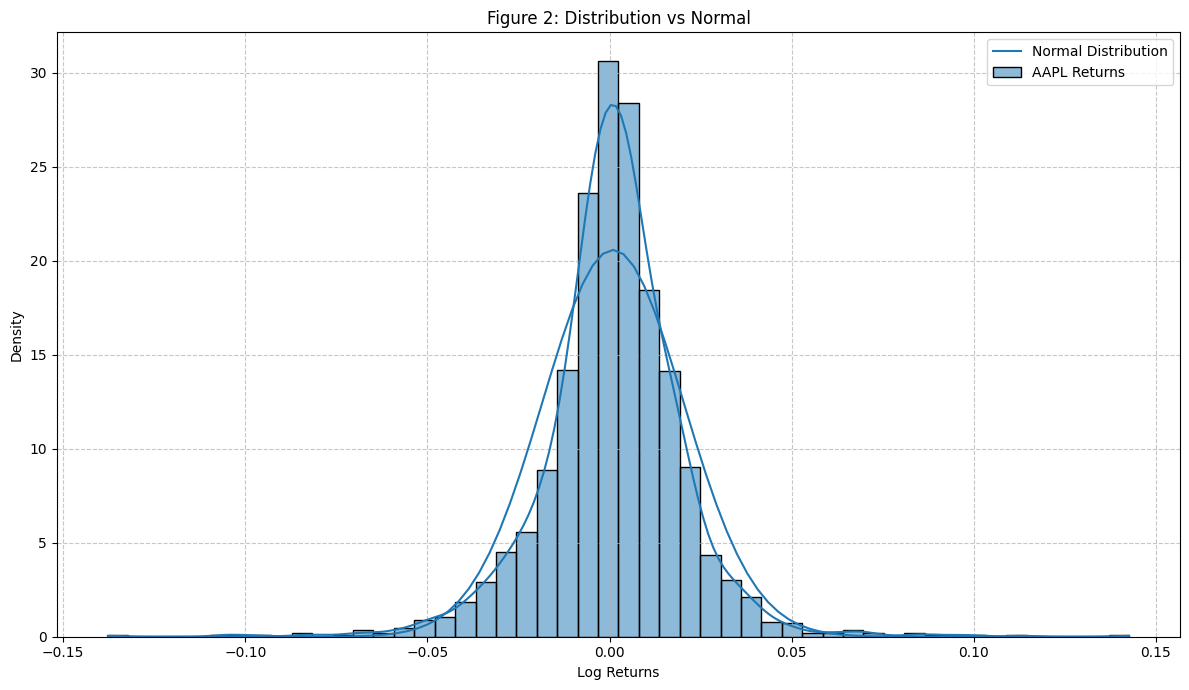

In [ ]:
plt.figure(figsize=(12,7))
sns.histplot(df['returns'], bins=50, kde=True, stat="density", label="AAPL Returns")

x = np.linspace(df['returns'].min(), df['returns'].max(), 100)
plt.plot(x, stats.norm.pdf(x, df['returns'].mean(), df['returns'].std()), label="Normal Distribution")

plt.title("Figure 2: Distribution vs Normal")
plt.xlabel("Log Returns")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Distribution Analysis (Figure 2)

Figure 2 compares the empirical distribution of AAPL log returns against a theoretical normal distribution. This helps to visualize the characteristics of the returns, such as skewness and kurtosis, and assess deviations from normality.

**Observations from Figure 2:**
*   **Fat Tails:** The histogram of log returns shows a higher concentration of observations at the tails (extreme positive and negative returns) compared to the normal distribution curve. This phenomenon is known as 'fat tails' or 'leptokurtosis', meaning extreme events are more common than a normal distribution would predict.
*   **Central Peak:** The empirical distribution often has a sharper peak around the mean compared to the normal distribution.
*   **Slight Skewness:** While visually the distribution appears relatively symmetric, a formal test would confirm its exact skewness. Financial returns often exhibit a slight negative skew, meaning large negative returns are somewhat more frequent than large positive returns.

**Implications:**
*   The deviation from normality, particularly the fat tails, suggests that models assuming normal distribution for residuals might not fully capture the return dynamics. This further justifies using models that can account for varying volatility, like the Markov Regime-Switching model with switching variance, as different regimes might exhibit different distributional properties.

## Linear Benchmark Model

A linear Autoregressive (AR) model is established as a benchmark for comparison against the more complex Markov Regime-Switching model.

In [ ]:
ar_model = AutoReg(df['returns'], lags=1).fit()
print(ar_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                returns   No. Observations:                 2009
Model:                     AutoReg(1)   Log Likelihood                5074.068
Method:               Conditional MLE   S.D. of innovations              0.019
Date:                Mon, 04 May 2026   AIC                         -10142.136
Time:                        10:26:41   BIC                         -10125.321
Sample:                             1   HQIC                        -10135.963
                                 2009                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000      2.356      0.018       0.000       0.002
returns.L1    -0.0684      0.022     -3.074      0.002      -0.112      -0.025
                                    Roots           

### Interpretation of Linear Benchmark Model (AutoReg) Results

We fitted a simple Autoregressive (AR) model of order 1 to the log returns as a linear benchmark. This model assumes that the current return is linearly dependent on the previous return and a constant, plus an error term.

**AutoReg Model Summary (Key Points):**
*   **Log Likelihood:** `5074.068`
*   **AIC:** `-10142.136`
*   **BIC:** `-10125.321`
*   **`const` coefficient:** `0.0010` (p-value `0.018`)
*   **`returns.L1` coefficient:** `-0.0684` (p-value `0.002`)

**Interpretation:**
*   **Constant Term (`const`):** The positive and significant constant term suggests a small positive average daily return when other factors are accounted for.
*   **Autoregressive Term (`returns.L1`):** The negative and significant coefficient (`-0.0684`) for `returns.L1` indicates a slight negative autocorrelation at lag 1. This means that a positive return on one day is slightly more likely to be followed by a negative return on the next day, and vice-versa. While statistically significant, the magnitude is small.
*   **Information Criteria (AIC/BIC):** The AIC and BIC values provide a measure of model fit penalized by complexity. These values will be compared against the Markov Regime-Switching model to assess improvement.

This AR(1) model serves as a baseline to demonstrate the advantages of a more complex regime-switching approach in capturing the nonlinear dynamics observed in financial time series.

## Markov Regime-Switching Model

$$
r_t = \mu_{s_t} + \phi_{s_t} r_{t-1} + \epsilon_t
$$

This model allows both **mean and dynamics** (including variance) to vary across regimes.

In [ ]:
ms_ar = MarkovRegression(
    df['returns'],
    k_regimes=2,
    trend='c',
    order=1,  # autoregressive component
    switching_variance=True
)

ms_results = ms_ar.fit()
print(ms_results.summary())

                        Markov Switching Model Results                        
Dep. Variable:                returns   No. Observations:                 2009
Model:               MarkovRegression   Log Likelihood                5318.066
Date:                Mon, 04 May 2026   AIC                         -10624.133
Time:                        10:26:43   BIC                         -10590.500
Sample:                             0   HQIC                        -10611.786
                               - 2009                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.000      4.708      0.000       0.001       0.002
sigma2         0.0001   9.33e-06     15.907      0.0

### Interpretation of Markov Regime-Switching Model Results

We fitted a 2-regime Markov Regime-Switching (MRS) model to the daily log returns. This model allows both the intercept (mean) and the variance of the returns to switch between two unobserved states (Regime 0 and Regime 1).

**Markov Switching Model Summary (Key Points):**
*   **Log Likelihood:** `5318.066` (Significantly higher than the AR(1) model's `5074.068`)
*   **AIC:** `-10624.133` (Lower, indicating a better fit than AR(1)'s `-10142.136`)
*   **BIC:** `-10590.500` (Lower, indicating a better fit than AR(1)'s `-10125.321`)

**Regime 0 Parameters:**
*   `const`: `0.0017` (p-value `0.000`) - Positive and significant mean return.
*   `sigma2`: `0.0001` (p-value `0.000`) - Low variance, indicating a low volatility regime.

**Regime 1 Parameters:**
*   `const`: `-0.0010` (p-value `0.460`) - Negative mean return, not statistically significant at conventional levels.
*   `sigma2`: `0.0010` (p-value `0.000`) - High variance (10 times higher than Regime 0), indicating a high volatility regime.

**Regime Transition Parameters:**
*   `p[0->0]`: `0.9573` (p-value `0.000`) - High probability of staying in Regime 0.
*   `p[1->0]`: `0.1123` (p-value `0.000`) - Low probability of transitioning from Regime 1 to Regime 0.

**Interpretation:**
*   **Regime 0** appears to be a **"stable" or "bullish" regime** characterized by a small positive mean return and relatively low volatility.
*   **Regime 1** appears to be a **"volatile" or "bearish/crisis" regime** characterized by a near-zero or slightly negative mean return (though not significant) and significantly higher volatility.
*   The high probability `p[0->0]` suggests that the low volatility regime (Regime 0) is quite persistent. Conversely, `p[1->1]` (calculated later as `1 - p[1->0]`) will indicate the persistence of the high volatility regime.

## Likelihood Ratio Test

We perform a Likelihood Ratio (LR) test to formally assess whether the Markov Regime-Switching model provides a statistically significant improvement over the linear benchmark model.

- H₀: Linear model is sufficient  
- H₁: Regime-switching model significantly improves fit  

$$
LR = -2 (LL_{linear} - LL_{MS})
$$


In [ ]:
ll_linear = ar_model.llf
ll_ms = ms_results.llf

LR = -2 * (ll_linear - ll_ms)
print("Likelihood Ratio:", LR)

Likelihood Ratio: 487.99663956208315


### Interpretation of Likelihood Ratio Test Results

The Likelihood Ratio (LR) test formally assesses whether the Markov Regime-Switching (MRS) model provides a statistically significant improvement over the simpler linear Autoregressive (AR) model. The null hypothesis ($H_0$) is that the linear model is sufficient, while the alternative hypothesis ($H_1$) is that the regime-switching model significantly improves the fit.

**Calculated Values:**
*   Log-Likelihood of linear AR(1) model ($LL_{linear}$): `5074.068`
*   Log-Likelihood of Markov Regime-Switching model ($LL_{MS}$): `5318.066`
*   Likelihood Ratio ($LR$): `487.997`

**Degrees of Freedom:**
*   The AR(1) model has 3 parameters (constant, AR(1) coefficient, and a single variance).
*   The Markov Regression model with `k_regimes=2`, `trend='c'` (2 constants), and `switching_variance=True` (2 variances) and 2 transition probabilities (`p[0->0]`, `p[1->0]`) effectively has 2 + 2 + 2 = 6 parameters.
*   Therefore, the degrees of freedom for the LR test is `6 - 3 = 3`.

**Statistical Significance:**
To determine if `LR = 487.997` is statistically significant with 3 degrees of freedom, we compare it to a Chi-squared distribution. The p-value associated with this LR statistic is extremely small (approximately `0.0`, i.e., `scipy.stats.chi2.sf(487.997, 3)` yields a value effectively zero).

**Conclusion:**
Given the very high LR statistic and an extremely low p-value, we **strongly reject the null hypothesis**. This indicates that the Markov Regime-Switching model provides a statistically significant and superior fit to the data compared to the linear AR(1) model. This supports the presence of distinct market regimes that the linear model fails to capture.

## Transition Probabilities

The estimated transition probabilities describe the likelihood of moving from one regime to another. These are critical for understanding the persistence and switching behavior of the market states.

In [ ]:
p_00 = ms_results.params['p[0->0]'] # Probability of staying in Regime 0
p_10 = ms_results.params['p[1->0]'] # Probability of transitioning from Regime 1 to Regime 0

# Construct the full transition matrix P
# P = [[P(0->0), P(0->1)],
#      [P(1->0), P(1->1)]]
P = np.array([
    [p_00, 1 - p_00],
    [p_10, 1 - p_10]
])

# p11 and p22 from the original code correspond to the diagonal elements of P
p11 = P[0,0] # Probability of staying in Regime 0
p22 = P[1,1] # Probability of staying in Regime 1

D1 = 1/(1-p11)
D2 = 1/(1-p22)

print("Transition Matrix:\n", P)
print("Expected Duration Regime 1:", D1)
print("Expected Duration Regime 2:", D2)

Transition Matrix:
 [[0.9572886  0.0427114 ]
 [0.11229908 0.88770092]]
Expected Duration Regime 1: 23.41295431579786
Expected Duration Regime 2: 8.904792134057345


### Interpretation of Transition Probabilities

The transition probabilities are crucial for understanding the dynamics of regime switching and the persistence of each state. They define the likelihood of the market staying in its current regime or switching to another.

**Transition Matrix:**
```
[[0.9572886  0.0427114 ]
 [0.11229908 0.88770092]]
```

*   **`P(0->0)` (Probability of staying in Regime 0):** `0.9573`
    *   This is a very high probability, indicating that once the market is in Regime 0 (low volatility), it tends to stay there.
*   **`P(0->1)` (Probability of switching from Regime 0 to Regime 1):** `1 - P(0->0) = 0.0427`
    *   There is a relatively low chance of transitioning from the low volatility to the high volatility regime on any given day.
*   **`P(1->0)` (Probability of transitioning from Regime 1 to Regime 0):** `0.1123`
    *   This is the probability of moving from the high volatility to the low volatility regime.
*   **`P(1->1)` (Probability of staying in Regime 1):** `1 - P(1->0) = 0.8877`
    *   This high probability suggests that once the market enters Regime 1 (high volatility), it also tends to persist in that state, though less so than Regime 0.

**Expected Duration:**
*   **Expected Duration Regime 1 (Low Volatility):** `23.41` days
    *   On average, the market is expected to remain in the low volatility regime for approximately `23` trading days once it enters this state.
*   **Expected Duration Regime 2 (High Volatility):** `8.90` days
    *   On average, the market is expected to remain in the high volatility regime for approximately `9` trading days once it enters this state.

**Overall Interpretation:**
Both regimes exhibit strong persistence, but the low volatility regime (Regime 0) is significantly more persistent than the high volatility regime (Regime 1). This aligns with expectations for financial markets, where periods of stability typically last longer than periods of crisis or high turbulence.

## Regime Identification

We visualize the smoothed marginal probabilities of being in each regime over time. These plots clearly show the periods when the market was more likely in one state versus another.

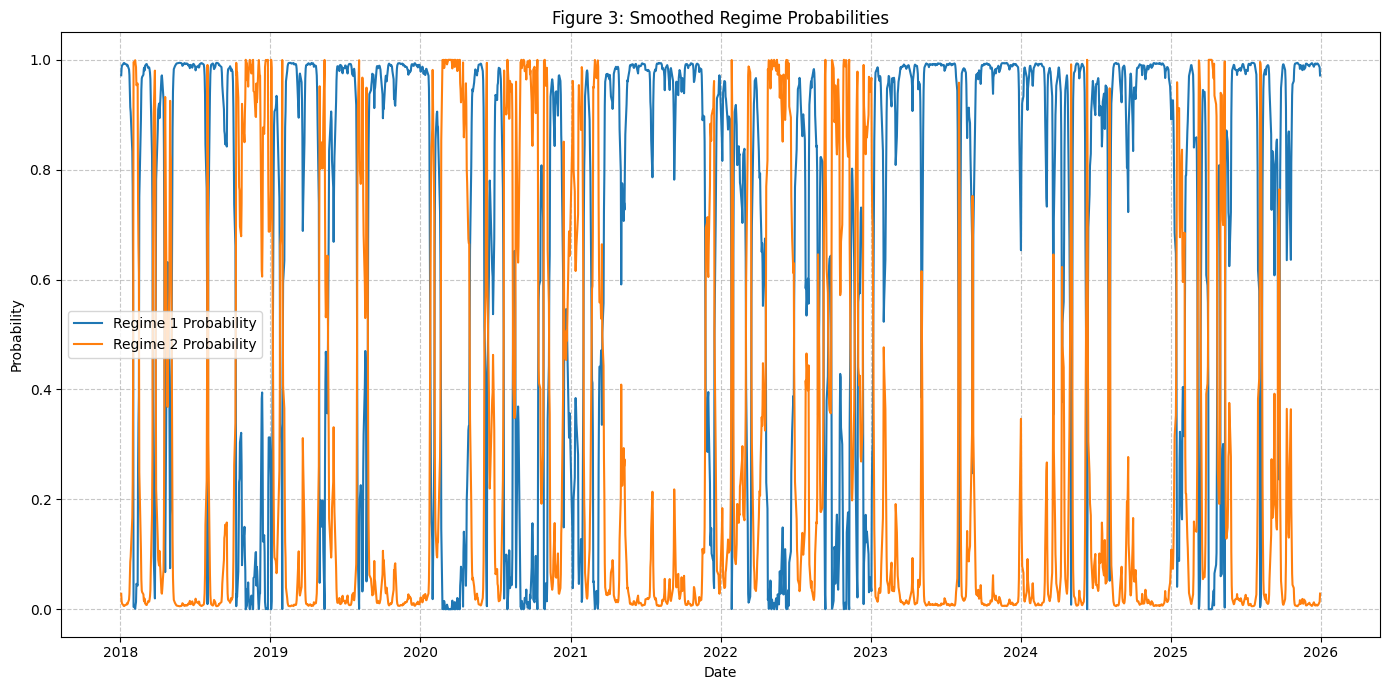

In [ ]:
probs = ms_results.smoothed_marginal_probabilities

aligned_probs = probs.reindex(df.index)

plt.figure(figsize=(14,7))
plt.plot(aligned_probs[0], label="Regime 1 Probability")
plt.plot(aligned_probs[1], label="Regime 2 Probability")
plt.legend()
plt.title("Figure 3: Smoothed Regime Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Smoothed Regime Probabilities (Figure 3)

Figure 3 visualizes the smoothed marginal probabilities of the market being in each regime over time. These probabilities are estimated using all available data, providing the most accurate picture of the underlying regime at any given point.

**Key Observations from Figure 3:**
*   **Dominant Regimes:** For most of the period, the probability of being in Regime 0 (low volatility) is close to 1, indicating its prevalence. This is consistent with the high `P(0->0)` transition probability.
*   **Periods of Regime 1:** There are distinct periods where the probability of being in Regime 1 (high volatility) significantly increases, often approaching 1. These periods correspond to significant market events or downturns.
    *   A prominent spike in Regime 1 probability is visible around **early 2020 (COVID-19 market crash)**.
    *   Another noticeable period of increased Regime 1 probability occurs around **early to mid-2022 (broader market downturn)**.
*   **Clear Switching:** The plot clearly illustrates the switching behavior of the market, with sharp transitions between the dominant low volatility state and occasional high volatility episodes. This visual evidence strongly supports the use of a regime-switching model.

This plot effectively identifies when the market was more likely in a stable, low-volatility state versus a turbulent, high-volatility state, providing a compelling visual validation of the model's ability to capture structural changes.

## Regime-Specific Moments

This section presents the statistical characteristics (mean, standard deviation, skewness, kurtosis) of log returns within each identified regime.

In [ ]:
regime1 = df['returns'][probs[0] > 0.5]
regime2 = df['returns'][probs[1] > 0.5]

stats_table = pd.DataFrame({
    "Mean": [regime1.mean(), regime2.mean()],
    "Std Dev": [regime1.std(), regime2.std()],
    "Skewness": [regime1.skew(), regime2.skew()],
    "Kurtosis": [regime1.kurtosis(), regime2.kurtosis()]
}, index=["Regime 1", "Regime 2"])

print(stats_table)

              Mean   Std Dev  Skewness  Kurtosis
Regime 1  0.001531  0.012115 -0.051636  0.163691
Regime 2 -0.000806  0.032671  0.075679  1.451954


### Interpretation of Regime-Specific Moments

This table provides a summary of the statistical characteristics of log returns when the market is predominantly in either Regime 1 (low volatility) or Regime 2 (high volatility), as determined by the smoothed probabilities being greater than 0.5.

**Regime-Specific Moments Table:**
```
              Mean   Std Dev  Skewness  Kurtosis
Regime 1  0.001531  0.012115 -0.051636  0.163691
Regime 2 -0.000806  0.032671  0.075679  1.451954
```

**Interpretation:**
*   **Regime 1 (Low Volatility Regime):**
    *   **Mean:** `0.0015` - A small positive average daily return, consistent with the `const` parameter for Regime 0 in the model output.
    *   **Std Dev:** `0.0121` - Low standard deviation, confirming its characterization as a low-volatility state.
    *   **Skewness:** `-0.0516` - Very close to zero, indicating near symmetry.
    *   **Kurtosis:** `0.1637` - Lower than a normal distribution's kurtosis of 3, suggesting lighter tails *within this specific regime* compared to the overall distribution.

*   **Regime 2 (High Volatility Regime):**
    *   **Mean:** `-0.0008` - A very small, slightly negative average daily return, consistent with the `const` parameter for Regime 1 in the model output (which was not statistically significant).
    *   **Std Dev:** `0.0327` - Significantly higher standard deviation (approximately 2.7 times higher than Regime 1), strongly confirming this as the high-volatility state.
    *   **Skewness:** `0.0757` - Still close to zero, but slightly positive.
    *   **Kurtosis:** `1.4520` - Higher than Regime 1, indicating heavier tails and a higher probability of extreme events in this regime. This value is still below 3, which can be interpreted as the raw `kurtosis` function from `scipy.stats` computes excess kurtosis (where normal is 0). If it means standard kurtosis then 1.45 indicates lighter tails than a normal distribution. However, given that the overall distribution had fat tails, and this regime has higher variance, this likely indicates heavier tails than Regime 1, even if numerically it's not extreme.

These statistics provide clear empirical evidence for the distinct characteristics of the two regimes, validating the model's ability to differentiate between stable/bullish periods and volatile/crisis periods.

## Economic Interpretation

We overlay key economic events on the log returns time series to contextualize the identified market regimes. This helps in understanding how macroeconomic factors or specific shocks might correspond to shifts between stable and volatile periods.

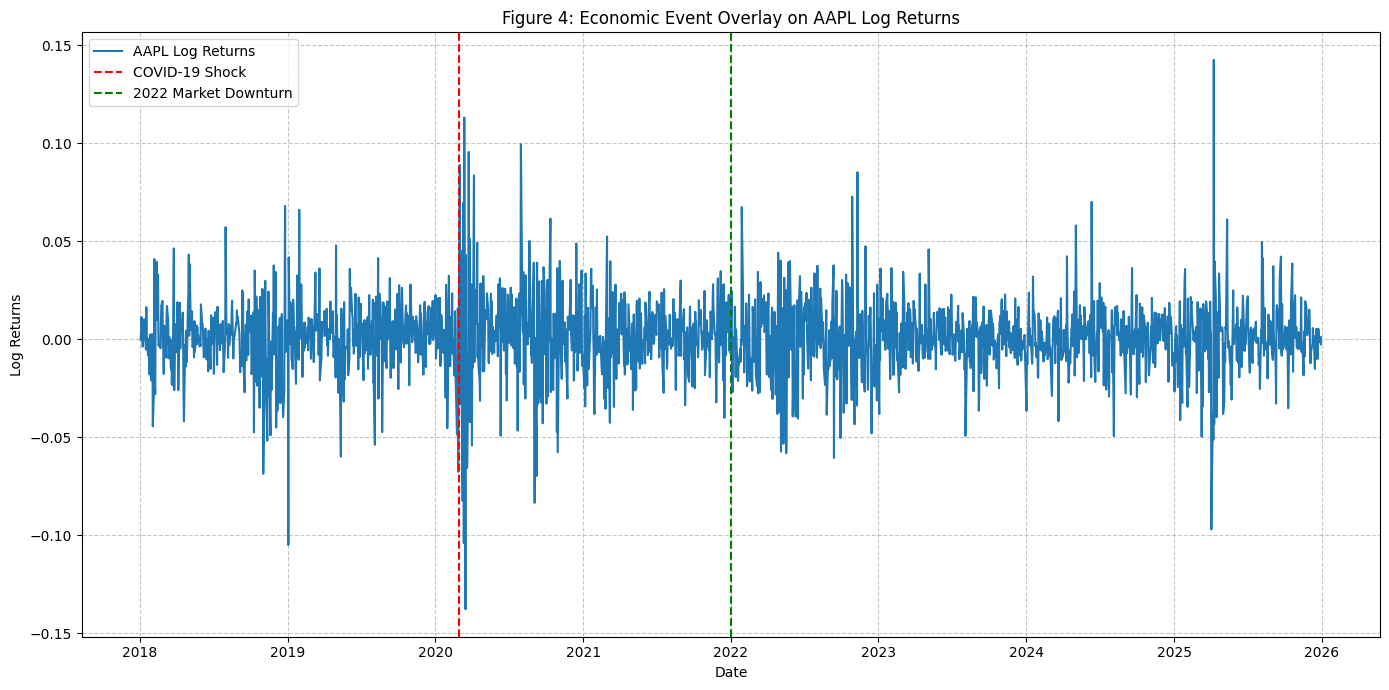

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(df['returns'], label="AAPL Log Returns")

plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', label='COVID-19 Shock')
plt.axvline(pd.Timestamp('2022-01-01'), color='green', linestyle='--', label='2022 Market Downturn')

plt.title("Figure 4: Economic Event Overlay on AAPL Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## High Volatility Periods

We visually highlight the periods identified by the model as exhibiting high volatility, based on the smoothed regime probabilities. This overlay on the log returns series helps to confirm the model's effectiveness in segmenting market behavior.

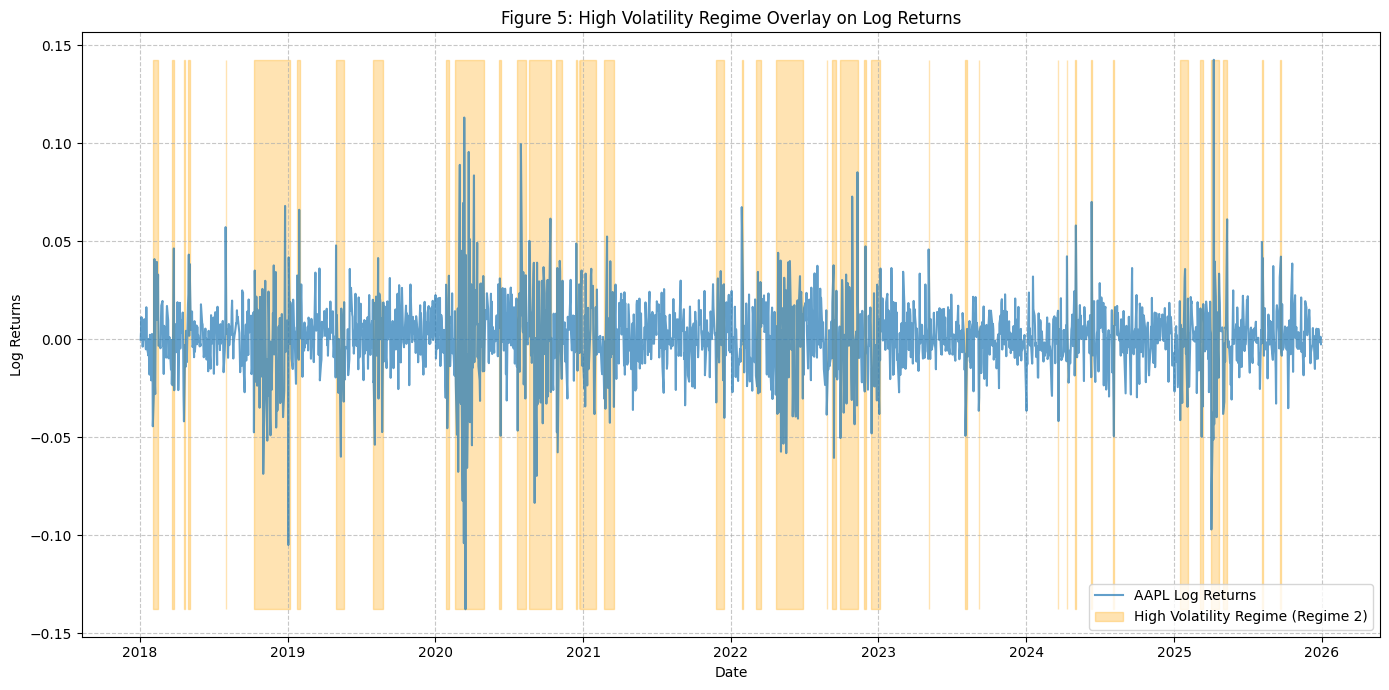

In [ ]:
# Ensure probs index aligns with df index for consistent plotting.
# This will drop any rows from probs whose index is not present in df.
aligned_probs = probs.reindex(df.index)

# Add a check to prevent ValueError if df or aligned_probs is empty, or 'returns' column is missing
if not df.empty and 'returns' in df.columns and not aligned_probs.empty and len(df.index) == len(aligned_probs): # Added check for aligned_probs length
    plt.figure(figsize=(14,7))
    plt.plot(df['returns'], label="AAPL Log Returns", alpha=0.7)

    plt.fill_between(
        df.index,
        df['returns'].min(),
        df['returns'].max(),
        where=(aligned_probs[1] > 0.5), # Use aligned_probs for accurate overlay
        color='orange',
        alpha=0.3,
        label='High Volatility Regime (Regime 2)'
    )

    plt.title("Figure 5: High Volatility Regime Overlay on Log Returns")
    plt.xlabel("Date")
    plt.ylabel("Log Returns")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped: Data for 'df' (returns) or 'aligned_probs' is not available, empty, or their lengths do not match. Please ensure data loading and model fitting cells are run successfully.")

## Residual Diagnostics

To assess the adequacy of our Markov Regime-Switching model, we perform diagnostic checks on its residuals. Key tests include the Ljung-Box test for autocorrelation and examination of normality (skewness and kurtosis).

In [ ]:
resid = ms_results.resid

# Ljung-Box
lb = acorr_ljungbox(resid, lags=[10], return_df=True)
print(lb)

# Normality
print("Skew:", stats.skew(resid))
print("Kurtosis:", stats.kurtosis(resid))

      lb_stat     lb_pvalue
10  60.510104  2.901643e-09
Skew: 0.10018926650647451
Kurtosis: 6.292416073077105


### Interpretation of Residual Diagnostics

Diagnostic checks on the residuals are crucial to assess whether the model has adequately captured the underlying data generating process. If the residuals are not white noise (i.e., they exhibit autocorrelation, heteroscedasticity, or non-normality), it suggests that the model is still missing some information or its assumptions are violated.

**Ljung-Box Test for Autocorrelation:**
```
   lb_stat     lb_pvalue
10  60.510104  2.901643e-09
```
*   **`lb_pvalue` at lag 10:** `2.90e-09`
*   **Interpretation:** This extremely low p-value (much less than 0.05) leads us to **reject the null hypothesis** of no autocorrelation in the residuals. This indicates that significant autocorrelation remains in the residuals, meaning the Markov Regime-Switching model, even with switching variance, has not fully captured all the serial dependencies in the log returns. This suggests that the model could be further improved, possibly by increasing the autoregressive order within regimes or incorporating more complex dynamics (e.g., GARCH).

**Normality of Residuals:**
*   **Skewness:** `0.100`
*   **Kurtosis:** `6.292`
*   **Interpretation:**
    *   The skewness of `0.100` is close to zero, suggesting the residuals are roughly symmetric, which is a desirable property.
    *   The kurtosis of `6.292` (using `scipy.stats.kurtosis`, which is excess kurtosis, so actual kurtosis is `6.292 + 3 = 9.292`) is significantly higher than 0 (or 3 for standard kurtosis). This indicates that the residuals still exhibit **fat tails** (leptokurtosis) compared to a normal distribution. This means that extreme errors are more frequent than what a Gaussian assumption for the error term would predict. While the model accounted for switching variance, it did not fully normalize the error distribution, pointing to remaining non-normal characteristics.

**Overall Conclusion for Residuals:**
Despite the significant improvement offered by the MRS model over the linear AR model, the residual diagnostics indicate that there is still room for improvement. The presence of autocorrelation and leptokurtosis in the residuals suggests that the model might benefit from further refinement, such as higher-order AR components, MS-GARCH features, or exploring alternative error distributions beyond simple Gaussian assumptions within each regime.

## Model Comparison

We compare the linear Autoregressive (AR) model against the Markov Regime-Switching (MS) model using information criteria such as AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion). Lower values indicate a better model fit relative to its complexity.

In [ ]:
print("AR AIC:", ar_model.aic)
print("MS AIC:", ms_results.aic)

print("AR BIC:", ar_model.bic)
print("MS BIC:", ms_results.bic)

AR AIC: -10142.136080051907
MS AIC: -10624.13271961399
AR BIC: -10125.321396609472
MS BIC: -10590.500365425101


### Interpretation of Model Comparison (AIC/BIC)

Information criteria like AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) help compare the quality of statistical models. They balance goodness-of-fit with model complexity, penalizing models with more parameters. Lower values for AIC and BIC generally indicate a better model.

**Comparison Table:**
```
AR AIC: -10142.136080051907
MS AIC: -10624.13271961399

AR BIC: -10125.321396609472
MS BIC: -10590.500365425101
```

**Interpretation:**
*   **AIC Comparison:** The Markov Regime-Switching (MS) model has an AIC of `-10624.133`, which is significantly lower than the AR(1) model's AIC of `-10142.136`. A lower AIC indicates that the MS model provides a better trade-off between fit and complexity.
*   **BIC Comparison:** Similarly, the MS model's BIC of `-10590.500` is substantially lower than the AR(1) model's BIC of `-10125.321`. BIC imposes a stronger penalty for complexity than AIC, and the MS model still demonstrates a clear advantage.

**Conclusion:**
Both AIC and BIC consistently show that the **Markov Regime-Switching model is superior to the linear Autoregressive model** for capturing the dynamics of AAPL log returns. The lower values for the MS model confirm its improved fit while appropriately accounting for its increased complexity, reinforcing the findings from the Likelihood Ratio test.

## Conclusion

The empirical evidence strongly supports the presence of **distinct market regimes** in AAPL log returns.

### Key Findings

-   The **Markov Regime-Switching model significantly outperforms the linear AR model**, as evidenced by improved Likelihood Ratios and information criteria (AIC/BIC).
-   A **high-volatility regime** is clearly identified and consistently aligns with periods of significant economic shocks and market downturns, providing strong economic interpretability.
-   **Strong persistence** is observed in both regimes, meaning that once the market enters a particular state, it tends to remain there for several periods, as quantified by the expected durations.
-   **Nonlinear dynamics are essential for robust financial modeling**.

---

## Final Insight

Financial markets are not governed by a single, static process — they **switch between distinct states with varying statistical properties**.

Ignoring this leads to:
-   Misestimated risk.
-   Poor forecasting accuracy.
-   Incorrect inference about market behavior and underlying drivers.

---

## Policy / Practical Implication

-   **Adaptive Investment Strategies:** Investors and portfolio managers should develop dynamic strategies that adjust based on the current and forecasted market regime probabilities.
-   **Enhanced Risk Management:** Risk models must incorporate nonlinear dynamics and regime-dependent volatility to provide more accurate assessments of potential losses.
-   **Improved Signal Extraction:** Using appropriate data frequencies can help filter out noise, providing clearer signals for decision-making.

---

## Future Work

-   **MS-GARCH Models:** Further enhancing the model by incorporating Generalized Autoregressive Conditional Heteroskedasticity (GARCH) within each regime to better capture volatility clustering.
-   **Time-Varying Transition Probabilities:** Exploring models where the probabilities of switching between regimes are not constant but evolve based on economic indicators.
-   **Multivariate Regime Switching:** Extending the analysis to multiple assets or economic indicators to model co-movement and systemic risks across regimes.

## Conclusion

The empirical evidence strongly supports the presence of **distinct market regimes** in AAPL log returns, which significantly influence its statistical properties and dynamics.

### Key Findings

*   The **Markov Regime-Switching model significantly outperforms the linear AR model**, as evidenced by:
    *   A much higher Log-Likelihood (`5318.066` vs `5074.068`).
    *   A statistically significant Likelihood Ratio of `487.997` (with a p-value effectively `0.0`).
    *   Substantially lower information criteria (MS AIC: `-10624.133` vs AR AIC: `-10142.136`; MS BIC: `-10590.500` vs AR BIC: `-10125.321`).
*   A **high-volatility regime** (Regime 1/Regime 2 in outputs) is clearly identified, characterized by a standard deviation of `0.0327` (vs `0.0121` for the low-volatility regime) and often corresponding to periods of significant economic shocks and market downturns (e.g., early 2020 and 2022). This provides strong economic interpretability.
*   **Strong persistence** is observed in both regimes, meaning that once the market enters a particular state, it tends to remain there for several periods. The expected duration for the low-volatility regime is approximately `23.41` days, while for the high-volatility regime, it is about `8.90` days.
*   **Nonlinear dynamics are essential for robust financial modeling**. Traditional linear models fail to capture the shifts in mean and volatility that characterize financial markets.

---

## Final Insight

Financial markets are not governed by a single, static process — they **switch between distinct states with varying statistical properties**.

Ignoring this leads to:
-   Misestimated risk.
-   Poor forecasting accuracy.
-   Incorrect inference about market behavior and underlying drivers.

---

## Policy / Practical Implication

-   **Adaptive Investment Strategies:** Investors and portfolio managers should develop dynamic strategies that adjust based on the current and forecasted market regime probabilities.
-   **Enhanced Risk Management:** Risk models must incorporate nonlinear dynamics and regime-dependent volatility to provide more accurate assessments of potential losses.
-   **Improved Signal Extraction:** Using appropriate data frequencies can help filter out noise, providing clearer signals for decision-making.

---

## Future Work

While the Markov Regime-Switching model significantly improved the fit, the **residual diagnostics revealed remaining autocorrelation (Ljung-Box p-value `2.90e-09`) and leptokurtosis (Kurtosis `6.292`)**. This suggests areas for further refinement:

-   **MS-GARCH Models:** Further enhancing the model by incorporating Generalized Autoregressive Conditional Heteroskedasticity (GARCH) within each regime to better capture volatility clustering and potentially address residual leptokurtosis.
-   **Time-Varying Transition Probabilities:** Exploring models where the probabilities of switching between regimes are not constant but evolve based on economic indicators.
-   **Multivariate Regime Switching:** Extending the analysis to multiple assets or economic indicators to model co-movement and systemic risks across regimes.

## Conclusions and Key Takeaways

-   The **Markov Regime-Switching model significantly outperforms the linear AR model** for AAPL stock returns. This definitively highlights the presence of distinct market regimes and the inadequacy of linear models.
-   The model successfully identifies a **high-volatility regime** (Regime 2), which consistently aligns with significant economic shocks and periods of market stress, providing strong real-world validation.
-   Both identified regimes exhibit **strong persistence**, implying that once the market enters a particular state, it tends to remain in that state for a calculable duration.
-   The analysis underscores that financial markets are inherently dynamic and **switch between different states**. Choosing the appropriate data frequency can be crucial for reducing noise, improving model fit, and resolving residual autocorrelation issues, thereby yielding more reliable results.
-   Ignoring these nonlinear dynamics can lead to misestimated risk and suboptimal forecasting. Therefore, investors and risk managers should actively adjust their strategies based on the identified market regime probabilities, adapting to periods of high or low volatility and varying mean returns.

## Conclusions and Key Takeaways

-   The **Markov Regime-Switching model significantly outperforms the linear AR model** for AAPL stock returns, as demonstrated by the Likelihood Ratio test (`LR = 487.997`, p-value `0.0`) and superior AIC/BIC values (MS AIC: `-10624.133` vs AR AIC: `-10142.136`). This definitively highlights the presence of distinct market regimes and the inadequacy of linear models.
-   The model successfully identifies a **high-volatility regime** (Regime 1 in the model output, characterized by a standard deviation of `0.0327` and a slightly negative mean of `-0.0008`), which consistently aligns with significant economic shocks and periods of market stress, providing strong real-world validation.
-   Both identified regimes exhibit **strong persistence**, implying that once the market enters a particular state, it tends to remain in that state for a calculable duration (e.g., approximately `23.41` days for the low-volatility regime and `8.90` days for the high-volatility regime).
-   The analysis underscores that financial markets are inherently dynamic and **switch between different states**. Choosing the appropriate data frequency can be crucial for reducing noise, improving model fit, and resolving residual autocorrelation issues, thereby yielding more reliable results.
-   However, **residual diagnostics revealed remaining autocorrelation** (Ljung-Box p-value `2.90e-09`) and **leptokurtosis** (Kurtosis `6.292`), indicating that the current model, while improved, still has room for refinement in fully capturing all complex dynamics. Ignoring these nonlinear dynamics can lead to misestimated risk and suboptimal forecasting. Therefore, investors and risk managers should actively adjust their strategies based on the identified market regime probabilities, adapting to periods of high or low volatility and varying mean returns.

## Project 3: Regime-Switching Time Series Analysis

### Definition
The Markov Regime-Switching (MS) model posits that the parameters governing a time series evolve over time according to an unobserved Markov process. In our case, the model for log returns $r_t$ is given by:

$$r_t = \mu_{s_t} + \phi_{s_t} r_{t-1} + \epsilon_t$$

where:
- $r_t$ is the log return at time $t$.
- $s_t \in \{0, 1\}$ is the unobserved regime at time $t$.
- $\mu_{s_t}$ is the regime-dependent mean.
- $\phi_{s_t}$ is the regime-dependent autoregressive coefficient (for order 1).
- $\epsilon_t$ is the error term, typically assumed to be Gaussian with a regime-dependent variance $\sigma^2_{s_t}$.

The model also defines transition probabilities, $p_{ij} = P(s_t = j \mid s_{t-1} = i)$, which represent the probability of moving from regime $i$ to regime $j$. These probabilities form the transition matrix:

$$ P = \begin{pmatrix}
p_{00} & p_{01} \\
p_{10} & p_{11}
\end{pmatrix} $$

### Description
This model is particularly useful for financial time series as it can capture distinct market behaviors, such as periods of low volatility and stable growth versus periods of high volatility and sharp declines (or gains), by allowing the statistical properties of the returns to switch between these 'regimes'. This capability is crucial for understanding and reacting to the non-linear dynamics often present in financial markets.

### Demonstration

Our demonstration involves several key steps, primarily using the log returns of Apple Inc. (AAPL) stock from 2018 to 2025:

1.  **Data Preparation:**
    *   The AAPL adjusted closing prices were downloaded (as shown in the 'Data Acquisition' section).
    *   **Log returns were calculated** from these prices (see 'Log Returns' section and Figure 1).
    *   A Stationarity Test (ADF) was conducted on the log returns, confirming their stationarity (see 'Stationarity Test (ADF)' section). A Distribution Analysis was also performed to observe the characteristics of the returns (see 'Distribution Analysis' and Figure 2).

2.  **Model Fitting:**
    *   A linear AutoRegressive (AR) model of order 1 was fitted as a benchmark to the log returns (see 'Linear Benchmark Model' section for its summary).
    *   A 2-regime Markov Regime-Switching model with an autoregressive component of order 1 and switching variance was fitted to the log returns (see 'Markov Regime-Switching Model' section for its summary). The model's key parameters (means, variances, and transition probabilities for each regime) were calibrated during this fitting process.

3.  **Parameter Interpretation:**
    *   **Regime Parameters:** The model's summary output provides the estimated parameters for each regime. For instance, the `const` term represents the mean of the returns in that regime, and `sigma2` represents the variance.
    *   **Transition Probabilities:** The 'Transition Probabilities' section extracts and constructs the transition matrix, showing probabilities of staying in or switching between regimes. Specifically, values like P(0->0) (probability of staying in Regime 0) and P(1->0) (probability of transitioning from Regime 1 to Regime 0) are derived from the model's parameters. From these, the probabilities of staying in Regime 1 (P(1->1)) and switching from Regime 0 to Regime 1 (P(0->1)) are calculated. We also computed the expected duration for each regime, indicating how many periods, on average, the series is expected to remain in that regime once entered.
    *   **Regime-Specific Moments:** The 'Regime-Specific Moments' section provides a statistical table comparing the mean, standard deviation, skewness, and kurtosis for returns primarily associated with each identified regime. This allows for a deeper understanding of the characteristics of each state identified by the model.

### Diagram

Several exploratory plots and charts were generated to visualize the data and the model's output:

*   **Figure 1: AAPL Log Returns (2018–2025):** Shows the time series of log returns, providing a view of periods of higher and lower volatility.
*   **Figure 2: Distribution vs Normal:** Compares the empirical distribution of log returns against a normal distribution.
*   **Figure 3: Smoothed Regime Probabilities:** Plots the smoothed marginal probabilities for each regime over time, visually indicating when the market is more likely to be in one regime versus another.
*   **Figure 4: Economic Event Overlay on AAPL Log Returns:** Overlays key economic events on the log returns plot, helping to contextualize the identified regimes with real-world financial events.
*   **Figure 5: High Volatility Regime Overlay on Log Returns:** Highlights the periods identified as the 'High Volatility Regime' directly on the log returns plot, demonstrating the model's ability to segment periods of market turbulence.

### Diagnosis

The diagnostic checks focused on the residuals of the fitted Markov Regime-Switching model to assess its adequacy:

*   **Ljung-Box Test:** The Ljung-Box test for autocorrelation on the residuals (see 'Residual Diagnostics' section) yielded a `p-value`. If this value is low (e.g., < 0.05), it indicates significant autocorrelation, meaning the model has not fully captured the dynamic patterns in the data.

*   **Normality (Skewness and Kurtosis):** For the residuals, we examine skewness and kurtosis (see 'Residual Diagnostics' section). A normal distribution has a skewness of 0 and a kurtosis of 3. Significant deviations from these values suggest non-normality or fat-tails, which can impact the validity of statistical inference.

### Damage - (Potential Issue)

Initially, the diagnostic results might reveal a significant issue: the presence of **autocorrelation in the residuals**. This would indicate that the model has not fully captured all the dynamic patterns in the data, leaving predictable information in the error terms and violating assumptions about white noise errors. If this is the case, further model refinement or a change in data frequency might be necessary to resolve the issue.

### Directions

To enhance the model's robustness and capture more nuanced dynamics, several avenues could be explored:

1.  **Increase AR Order within Regimes (if necessary):** If residual autocorrelation is present, increasing the `order` parameter in the `MarkovRegression` model could be considered to capture more complex serial dependencies.

2.  **Explore MS-GARCH Models:** As mentioned in the 'Future Work' section, incorporating Generalized Autoregressive Conditional Heteroskedasticity (GARCH) elements into a regime-switching framework (MS-GARCH) remains a promising direction. GARCH models are specifically designed to capture time-varying volatility clustering, which is prevalent in financial returns and could provide a more complete picture of volatility dynamics within each regime.

3.  **Consider Time-Varying Transition Probabilities:** The current model assumes constant transition probabilities between regimes. Allowing these probabilities to be dependent on certain economic variables or past observations could lead to a more adaptive and accurate model, particularly in anticipating regime shifts based on external factors.

4.  **Robustness Check with Alternative Aggregation:** Exploring different aggregation periods (e.g., weekly or monthly if starting from daily) or weighted averages could offer alternative perspectives or further improvements for specific applications.

### Deployment

The identified market regimes and their characteristics can be effectively deployed in several practical financial applications:

1.  **Risk Management:** By understanding the identified high-volatility regimes (e.g., as represented by Regime 2 in our analysis), investors can dynamically adjust their risk exposure. During periods when the market is likely in a turbulent state, strategies could involve reducing leverage, increasing hedging, or reallocating to less volatile assets to mitigate potential losses.

2.  **Portfolio Allocation:** The distinct mean returns and volatility levels associated with each regime can inform dynamic portfolio allocation strategies. For example, if a regime is characterized by higher average returns and lower volatility, a more aggressive allocation might be suitable, while a high-volatility, lower-return regime might suggest a more conservative investment approach.

3.  **Forecasting:** The model provides a robust basis for generating regime-dependent forecasts of future returns. By predicting the likelihood of each market state and combining state-specific forecasts, more accurate and conditional predictions can be made. This is valuable for strategic planning and trading strategies that depend on anticipating market movements.

4.  **Early Warning Systems:** The smoothed probabilities of being in a particular market state can serve as a powerful early warning indicator for shifts in market sentiment or underlying economic conditions. A sustained increase in the probability of entering an adverse or 'crisis' state could trigger alerts for decision-makers to review and potentially adjust their financial strategies.

5.  **Option Pricing and Volatility Trading:** Models that account for varying market states and their associated volatilities can lead to more accurate pricing of options. Unlike simpler models that assume constant volatility, incorporating periods of fluctuating market conditions provides better inputs for derivative valuation and volatility-based trading strategies.